# PANSS pseudo-real data: two-instrument G-estimation of total, direct, and indirect NNT

This notebook applies the **G-estimation strategy from the original simulation notebook** to one fixed PANSS-based pseudo-real dataset.

The analysis is restricted to the setting selected by the simulation study:

- The observed confounder $L$ is included in every fitted nuisance model.
- The unmeasured confounder $U$ is present in the data-generating mechanism but is hidden from the estimator.
- $Z_1$ is used as the instrument for treatment $A$.
- $Z_2$ is used as the instrument for the continuous mediator $M=\text{PANSS5}$.

The required adaptation is that the mediator is continuous rather than binary.

## 1. Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import statsmodels.api as sm

from scipy.special import expit
from scipy.optimize import root, root_scalar
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 6)

## 2. Generate one fixed PANSS-based pseudo-real dataset

The data-generating function is used once to create the dataset. After generation, the sample is treated as an observational dataset.

Although the generator creates $U$ and the true treatment probability $p_A$, neither variable is available to the estimation procedure.

In [2]:
def simulate_panss_based_data(N=5000, with_u=True, seed=42):
    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # Z1: Instrument for treatment assignment.
    # Clinical interpretation:
    # Z1 represents physician or medical center prescribing preference
    # for Paliperidone.
    #
    # IV assumptions:
    # 1. Z1 affects A, the probability of receiving Paliperidone.
    # 2. Z1 does not directly affect the mediator or the outcome,
    #    except through treatment A.
    # 3. Z1 is independent of the unmeasured confounder U.
    # --------------------------------------------------
    Z1 = rng.binomial(1, 0.5, N)

    # --------------------------------------------------
    # Z2: Instrument for the measured PANSS mediator.
    # Clinical interpretation:
    # Z2 represents PANSS rater calibration or site-level PANSS scoring tendency.
    # In a multi-center study, some raters/sites may systematically score PANSS
    # slightly lower or identify symptom improvement more readily.
    #
    # IV assumptions:
    # 1. Z2 affects the measured PANSS score at week 5.
    # 2. Z2 does not directly affect PSP improvement Y.
    # 3. Z2 is independent of the unmeasured confounder U.
    # 4. Z2 is not related to treatment assignment A.
    # --------------------------------------------------
    Z2 = rng.binomial(1, 0.5, N)

    # --------------------------------------------------
    # Baseline variables based on the PANSS paper
    # --------------------------------------------------
    bmi0 = np.clip(rng.normal(26, 6, N), 15, 42)
    panss0 = np.clip(rng.normal(47, 7.5, N), 31, 76)
    psp0 = np.clip(rng.normal(49, 15, N), 20, 90)
    sas0 = np.clip(rng.normal(3, 5, N), 0, 35)

    # --------------------------------------------------
    # L: Measured baseline severity.
    # Higher L means worse measured baseline condition:
    # - Higher baseline PANSS increases L.
    # - Lower baseline PSP increases L.
    # - Higher BMI and SAS slightly increase L.
    #
    # L is observed by the researcher and can be adjusted for.
    # --------------------------------------------------
    L = (
        0.50 * ((panss0 - 47) / 7.5)
        - 0.40 * ((psp0 - 49) / 15)
        + 0.15 * ((bmi0 - 26) / 6)
        + 0.15 * ((sas0 - 3) / 5)
    )

    # --------------------------------------------------
    # U: Unmeasured confounder.
    # Clinical interpretation:
    # U represents latent disease severity, cognition,
    # adherence, family support, or other unmeasured factors.
    #
    # U affects:
    # - A: probability of receiving treatment.
    # - panss5: symptom severity at week 5.
    # - psp6 / Y: social functioning improvement.
    #
    # U is generated in the simulation, but in the actual analysis
    # it should be treated as unobserved.
    # --------------------------------------------------
    U = rng.normal(0, 1, N)

    # --------------------------------------------------
    # Control whether unmeasured confounding exists.
    # with_u=True creates unmeasured confounding.
    # with_u=False removes the effect of U.
    # --------------------------------------------------
    if not with_u:
        U_effect_A = 0.0
        U_effect_PANSS = 0.0
        U_effect_PSP = 0.0
        U_effect_WG = 0.0
        U_effect_SAS = 0.0
    else:
        U_effect_A = 0.8
        U_effect_PANSS = 3.0
        U_effect_PSP = -3.0
        U_effect_WG = 0.01
        U_effect_SAS = 0.5

    # --------------------------------------------------
    # A: Treatment assignment.
    # A = 1 means the patient receives Paliperidone.
    # A = 0 means the patient receives placebo / no Paliperidone.
    #
    # In the original PANSS paper, treatment was randomized.
    # In this simulation, treatment assignment is observational:
    # A depends on Z1, measured severity L, and unmeasured confounding U.
    # --------------------------------------------------
    p_A = expit(
        -0.30
        + 1.20 * Z1
        + 0.60 * L
        + U_effect_A * U
    )
    A = rng.binomial(1, p_A)

    # --------------------------------------------------
    # panss5: PANSS score at week 5.
    # This is the main continuous mediator.
    #
    # In this simulation:
    # - A lowers PANSS, representing treatment benefit.
    # - Z2 lowers measured PANSS, representing rater/site scoring tendency.
    # - L and U increase PANSS, representing worse measured and unmeasured severity.
    # --------------------------------------------------
    panss5 = (
        37.5
        - 4.0 * A
        - 2.0 * Z2
        + 4.0 * L
        + U_effect_PANSS * U
        + rng.normal(0, 8.5, N)
    )
    panss5 = np.clip(panss5, 7, 90)

    # --------------------------------------------------
    # wg: Percent weight gain after treatment.
    # WG appears in the PANSS paper as a possible adverse-event variable.
    #
    # In the main project simulation, WG is not the central mediator.
    # We keep it to preserve part of the clinical story of the PANSS paper.
    # --------------------------------------------------
    wg = (
        -0.01
        + 0.03 * A
        + 0.01 * L
        + U_effect_WG * U
        + rng.normal(0, 0.045, N)
    )
    wg = np.clip(wg, -0.10, 0.40)

    # --------------------------------------------------
    # sas_max: Maximum SAS score after baseline.
    # SAS represents extrapyramidal / motor adverse events.
    #
    # In the PANSS paper, SAS was examined as a possible mediator,
    # but it was not statistically significant in the final mediation analysis.
    # Therefore, we keep SAS as a secondary clinical variable.
    # --------------------------------------------------
    sas_max = (
        2.8
        + 0.7 * A
        + 0.8 * L
        + U_effect_SAS * U
        + rng.normal(0, 5.5, N)
    )
    sas_max = np.clip(sas_max, 0, 35)

    # --------------------------------------------------
    # psp6: PSP score at week 6.
    # PSP measures personal and social functioning.
    # Higher PSP means better social functioning.
    #
    # Main mediation pathway:
    # A affects continuous PANSS at week 5,
    # and PANSS affects PSP at week 6.
    #
    # In this simulation:
    # - A has a direct effect on PSP.
    # - panss5 affects PSP as the main clinical mediator.
    # - WG and SAS are included as secondary clinical factors.
    # - L and U affect PSP, creating measured and unmeasured confounding.
    # --------------------------------------------------
    psp6 = (
        psp0
        + 5.0 * A
        - 0.85 * (panss5 - 37.5)
        + 35.0 * wg
        - 120.0 * (wg ** 2)
        - 0.10 * sas_max
        - 1.0 * L
        + U_effect_PSP * U
        + rng.normal(0, 10, N)
    )
    psp6 = np.clip(psp6, 1, 100)

    # --------------------------------------------------
    # Y: Binary outcome.
    # Y = 1 means clinically meaningful improvement in social functioning.
    # Y = 0 means no clinically meaningful improvement.
    #
    # Following the project advisor's comment, we define clinically
    # meaningful improvement as an increase of at least one standard
    # deviation in PSP from baseline to week 6.
    #
    # In the PANSS-based simulation, baseline PSP was generated with
    # an SD of approximately 15 points, consistent with the PSP
    # variability reported in the PANSS study.
    #
    # This binary outcome is needed because NNT, NNE, and EIN
    # are based on event probabilities.
    # --------------------------------------------------
    PSP_ONE_SD = 15.0
    Y = ((psp6 - psp0) >= PSP_ONE_SD).astype(int)

    # --------------------------------------------------
    # Return the simulated dataset.
    #
    # Important:
    # U is returned only for simulation validation. In the actual
    # estimation step, U should be removed or ignored to mimic a real
    # observational study with unmeasured confounding.
    # --------------------------------------------------
    df = pd.DataFrame({
        "Z1": Z1,
        "Z2": Z2,
        "L": L,
        "U": U,
        "A": A,
        "Y": Y,
        "bmi0": bmi0,
        "panss0": panss0,
        "panss5": panss5,
        "psp0": psp0,
        "psp6": psp6,
        "wg": wg,
        "sas0": sas0,
        "sas_max": sas_max,
        "p_A": p_A,
    })

    return df

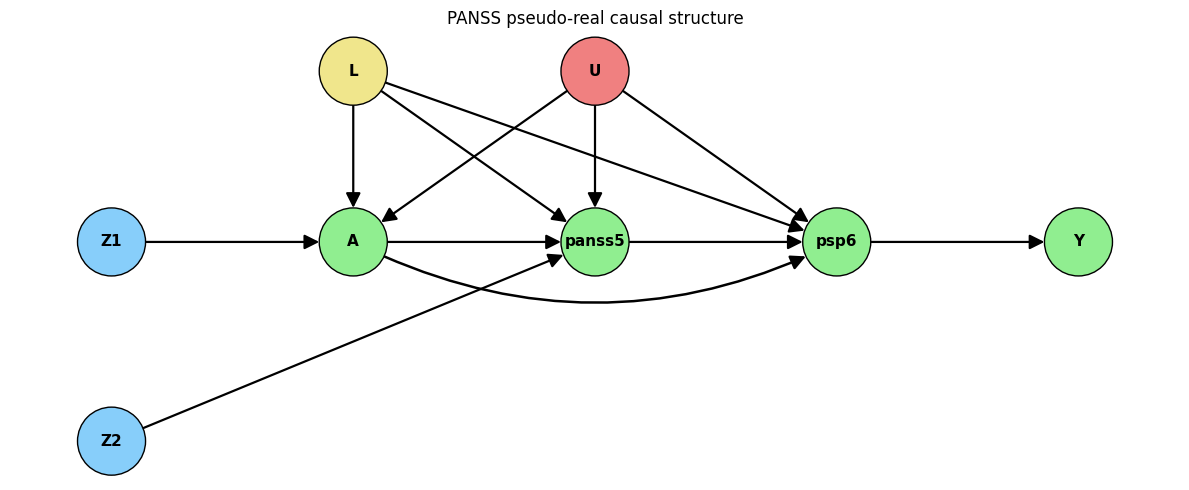

In [3]:
def draw_dag():
    graph = nx.DiGraph()

    regular_edges = [
        ("Z1", "A"),
        ("Z2", "panss5"),
        ("A", "panss5"),
        ("panss5", "psp6"),
        ("psp6", "Y"),
        ("L", "A"),
        ("L", "panss5"),
        ("L", "psp6"),
        ("U", "A"),
        ("U", "panss5"),
        ("U", "psp6"),
    ]
    curved_edges = [("A", "psp6")]
    graph.add_edges_from(regular_edges + curved_edges)

    pos = {
        "Z1": (0.0, 1.6),
        "Z2": (0.0, 0.2),
        "L": (2.0, 2.8),
        "A": (2.0, 1.6),
        "U": (4.0, 2.8),
        "panss5": (4.0, 1.6),
        "psp6": (6.0, 1.6),
        "Y": (8.0, 1.6),
    }

    node_colors = {
        "Z1": "lightskyblue",
        "Z2": "lightskyblue",
        "U": "lightcoral",
        "L": "khaki",
        "A": "lightgreen",
        "panss5": "lightgreen",
        "psp6": "lightgreen",
        "Y": "lightgreen",
    }

    plt.figure(figsize=(12, 5))
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color=[node_colors[node] for node in graph.nodes],
        node_size=2400,
        edgecolors="black",
    )
    nx.draw_networkx_labels(graph, pos, font_size=11, font_weight="bold")
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=regular_edges,
        arrows=True,
        arrowsize=22,
        width=1.6,
        node_size=2400,
    )
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=curved_edges,
        arrows=True,
        arrowsize=22,
        width=1.8,
        node_size=2400,
        connectionstyle="arc3,rad=0.25",
    )
    plt.title("PANSS pseudo-real causal structure")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


draw_dag()


## 3. Create the analysis sample

In [4]:
SEED = 42
N = 10_000

df_full = simulate_panss_based_data(
    N=N,
    with_u=True,
    seed=SEED,
)

analysis_columns = ["A", "panss5", "Y", "L", "Z1", "Z2"]
df_analysis = df_full[analysis_columns].copy()

print(f"Sample size: {len(df_analysis):,}")
display(df_analysis.head())

Sample size: 10,000


,A,panss5,Y,L,Z1,Z2
0,1,33.109985,0,-0.074024,1,1
1,1,23.781240,0,0.712833,0,1
2,1,32.176976,0,-0.141939,1,0
3,0,27.099708,0,0.475444,1,0
4,0,41.580047,0,0.194137,0,0


## 4. Descriptive checks

These summaries describe the fixed pseudo-real sample. They are not causal estimates.

The binary outcome is defined as

$$
Y = 1\{PSP_6 - PSP_0 \geq 15\}.
$$

Thus, $Y=1$ means an improvement of at least one baseline PSP standard deviation, using the approximate PSP standard deviation reported in the PANSS study and used in the simulation.


In [5]:
print("Overall means")
display(df_analysis.mean().to_frame("mean"))

print("\nObserved outcome and mediator by treatment")
display(
    df_full.groupby("A")[["panss0", "panss5", "psp0", "psp6", "Y"]].mean()
)

print("\nInstrument Z1 and treatment")
display(df_analysis.groupby("Z1")[["A", "Y"]].mean())

print("\nInstrument Z2 and mediator")
display(df_analysis.groupby("Z2")[["A", "panss5", "Y"]].mean())

Overall means


,mean
A,0.565200
panss5,34.203892
Y,0.238600
L,0.016251
Z1,0.498500
Z2,0.507700



Observed outcome and mediator by treatment


,panss0,panss5,psp0,psp6,Y
A,,,,,
0,46.148233,34.846600,50.855568,53.101669,0.178243
1,47.654498,33.709467,47.976551,55.341643,0.285032



Instrument Z1 and treatment


,A,Y
Z1,,
0,0.439880,0.209571
1,0.691274,0.267803



Instrument Z2 and mediator


,A,panss5,Y
Z2,,,
0,0.574040,35.226784,0.223644
1,0.556628,33.212028,0.253102


### Interpretation of the descriptive checks

The observed event rate is approximately 0.179 among untreated subjects and 0.285 among treated subjects. These are descriptive differences only, they do not have a causal interpretation because treatment assignment is observational and depends on measured severity $L$ and unmeasured severity $U$.

The instrument checks are consistent with the intended data-generating structure. $Z_1$ shifts treatment assignment substantially, from approximately 0.440 to 0.691. $Z_2$ shifts the continuous PANSS mediator, with mean PANSS5 decreasing from approximately 35.23 to 33.21, while treatment rates remain similar across $Z_2$ groups. These checks support the relevance of the instruments in the simulated sample. In addition, because the data-generating mechanism is known, the instrumental-variable validity assumptions are imposed by construction: $Z_1$ is generated independently of the measured severity $L$ and the unmeasured severity $U$, and it appears only in the treatment-assignment equation. Similarly, $Z_2$ is generated independently of $L$ and $U$, and it appears only in the PANSS5 mediator equation. Neither instrument is included directly in the outcome equation. Therefore, within this simulation, $Z_1$ can affect the outcome only through treatment assignment, and $Z_2$ can affect the outcome only through the PANSS mediator. In real observational data these assumptions cannot generally be proven from descriptive checks alone, but in this simulation they follow from the known data-generating mechanism.



## 5. Causal estimands

Let $M(a)$ denote the PANSS mediator under treatment level $a$, and let $Y(a,m)$ denote the binary PSP-improvement outcome under treatment $a$ and mediator value $m$.

The three risks required for the mediation decomposition are

$$
R_{1M(1)}=\mathbb{E}\!\left[Y\{1,M(1)\}\right],
\qquad
R_{0M(0)}=\mathbb{E}\!\left[Y\{0,M(0)\}\right],
\qquad
R_{1M(0)}=\mathbb{E}\!\left[Y\{1,M(0)\}\right]
$$

The risk-difference effects are

$$
\begin{aligned}
RD_{\mathrm{total}} &= R_{1M(1)}-R_{0M(0)}\\
RD_{\mathrm{direct}} &= R_{1M(0)}-R_{0M(0)}\\
RD_{\mathrm{indirect}} &= R_{1M(1)}-R_{1M(0)}
\end{aligned}
$$

Therefore,

$$
RD_{\mathrm{total}}
=
RD_{\mathrm{direct}}
+
RD_{\mathrm{indirect}}
$$

For each component $k$, the signed NNT is

$$
{NNT}_{k}
=
\frac{1}{{RD}_{k}}
\qquad
k \in \{\text{total}, \text{direct}, \text{indirect}\},
$$

In [6]:
def nnt_from_rd(rd, tol=1e-10):
    if pd.isna(rd):
        return np.nan
    # if rd is very small, than NNT will be extreamly big
    # with no effective meaning
    if abs(float(rd)) < tol:
        return np.inf
    return 1.0 / float(rd)


def add_nnt_cols(results, tol=1e-10):
    output = dict(results)
    for component in ["total", "direct", "indirect"]:
        rd_key = f"{component}_rd"
        if rd_key in output:
            output[f"{component}_nnt"] = nnt_from_rd(
                output[rd_key],
                tol=tol,
            )
    return output

## 6. Instrument relevance adjusted for $L$

We will use OLS only as a simple first-stage relevance check for the instruments. Even when the target variable is binary, OLS can be interpreted as a linear probability model, so the coefficient gives an easily interpretable adjusted difference in probability. A logistic model could also be used, but its coefficients are on the log-odds scale and are less direct for this diagnostic purpose. Therefore, OLS is preferred here for simplicity and interpretability.<br>
For the treatment instrument,

$$
A=\gamma_0+\gamma_1 Z_1+\gamma_L L+\varepsilon_A.
$$

For the mediator instrument,

$$
M=\delta_0+\delta_1 Z_2+\delta_A A+\delta_L L+\varepsilon_M.
$$

Large squared robust $t$-statistics support relevance. They do not establish instrument independence or the exclusion restriction.

In [7]:
def instrument_relevance_table(df):
    fit_z1 = sm.OLS(
        df["A"],
        sm.add_constant(df[["Z1", "L"]], has_constant="add"),
    ).fit(cov_type="HC1")

    fit_z2 = sm.OLS(
        df["panss5"],
        sm.add_constant(df[["Z2", "A", "L"]], has_constant="add"),
    ).fit(cov_type="HC1")

    return pd.DataFrame([
        {
            "instrument": "Z1 for A",
            "coefficient": fit_z1.params["Z1"],
            "robust_se": fit_z1.bse["Z1"],
            "p_value": fit_z1.pvalues["Z1"],
            "robust_t_squared": fit_z1.tvalues["Z1"] ** 2,
        },
        {
            "instrument": "Z2 for panss5",
            "coefficient": fit_z2.params["Z2"],
            "robust_se": fit_z2.bse["Z2"],
            "p_value": fit_z2.pvalues["Z2"],
            "robust_t_squared": fit_z2.tvalues["Z2"] ** 2,
        },
    ])


relevance_results = instrument_relevance_table(df_analysis)
display(relevance_results)

,instrument,coefficient,robust_se,p_value,robust_t_squared
0,Z1 for A,0.252223,0.009475,3.970827e-156,708.630870
1,Z2 for panss5,-2.024778,0.180191,2.688351e-29,126.266564


The very small p-values and large robust squared t-statistics indicate that weak instrument concerns are unlikely in this simulated setting.

## 7. G-estimation with a continuous mediator

### 7.1 Mediator blip

We use the additive structural model

$$
M(a)=M(0)+\theta a
$$

For an observed subject, the mediator blipped down to the no-treatment state is

$$
H_M(\theta)=M-\theta A
$$

The causal parameter $\theta$ is selected so that the blipped-down mediator is orthogonal to the treatment instrument:

$$
\sum_{i=1}^{n}
(Z_{1i}-\bar{Z}_1)
H_{M,i}(\theta)
=0
$$

As in the original simulation notebook, a nuisance association model that includes $L$ is fitted first:

$$
\mathbb{E}(M\mid A,Z_1,Z_2,L)
$$

For the continuous mediator, the individual counterfactual mediator values are constructed by preserving each subject's fitted residual:

$$
\widehat{M}_i(0)=M_i-\widehat{\theta} A_i
$$

$$
\widehat{M}_i(1)=M_i+\widehat{\theta}(1-A_i)
$$

### 7.2 Outcome blips

A logistic association model is fitted:

$$
\operatorname{logit}
\Pr(Y=1\mid A,M,Z_1,Z_2,L)
=
\eta(A,M,Z_1,Z_2,L)
$$

The blipped-down outcome risk under $A=0$ and $M=0$ is

$$
H_Y(\psi_A,\psi_M)
=
\operatorname{expit}
\left\{
\eta-\psi_A A-\psi_M M
\right\}
$$

The two causal blip parameters solve

$$
\sum_{i=1}^{n}
(Z_{1i}-\bar{Z}_1)
H_{Y,i}(\psi_A,\psi_M)
=0
$$

$$
\sum_{i=1}^{n}
(Z_{2i}-\bar{Z}_2)
H_{Y,i}(\psi_A,\psi_M)
=0
$$

### 7.3 Counterfactual risks

For arbitrary $a$ and $m$,

$$
\widehat{p}_i(a,m)
=
\operatorname{expit}
\left[
\widehat{\eta}_i
+
\widehat{\psi}_A(a-A_i)
+
\widehat{\psi}_M(m-M_i)
\right]
$$

The standardized risks are

$$
\widehat{R}_{1M(1)}
=
\frac{1}{n}\sum_{i=1}^{n}
\widehat{p}_i\{1,\widehat{M}_i(1)\}
$$

$$
\widehat{R}_{0M(0)}
=
\frac{1}{n}\sum_{i=1}^{n}
\widehat{p}_i\{0,\widehat{M}_i(0)\}
$$

$$
\widehat{R}_{1M(0)}
=
\frac{1}{n}\sum_{i=1}^{n}
\widehat{p}_i\{1,\widehat{M}_i(0)\}
$$

This is the continuous-mediator adaptation of the two-instrument G-estimation prototype in the original simulation notebook.

In [8]:
def _fit_logit(y, X):
    # logistic regression
    X_design = sm.add_constant(X, has_constant="add")
    return sm.GLM(
        y,
        X_design,
        family=sm.families.Binomial(),
    ).fit()


def _solve_one_dim(fun, x0=0.0):
    # This function receives an estimating equation from the G-estimation,
    # it returns the parameter value that makes this equation equal to zero.
    grid = np.linspace(-20.0, 20.0, 161)
    values = [fun(value) for value in grid]

    for lo, hi, f_lo, f_hi in zip(
        grid[:-1],
        grid[1:],
        values[:-1],
        values[1:],
    ):
        if (
            np.isfinite(f_lo)
            and np.isfinite(f_hi)
            and f_lo * f_hi <= 0
        ):
            return float(root_scalar(fun, bracket=[lo, hi]).root)

    solution = root(
        lambda parameter: [fun(parameter[0])],
        [x0],
    )

    if not solution.success:
        raise RuntimeError(
            "The one-dimensional G-estimation equation did not converge."
        )

    return float(solution.x[0])


def _solve_outcome_blips(equations, association_start):
    # This function receives two G-estimation equations
    # Finds the two effect parameters for the outcome model:
    # one for the treatment and one for the mediator. 
    # It returns the values that make both equations equal to zero.
    starts = [
        np.array([0.50, -0.05]),
        np.array([1.00, -0.10]),
        np.array([0.25, -0.02]),
        np.asarray(association_start, dtype=float),
        np.array([0.00, 0.00]),
    ]

    candidates = []

    for start in starts:
        solution = root(equations, x0=start)
        moment_norm = float(np.linalg.norm(equations(solution.x)))

        psi_a, psi_m = solution.x
        plausible_scale = abs(psi_a) <= 8.0 and abs(psi_m) <= 1.0

        if (
            solution.success
            and np.all(np.isfinite(solution.x))
            and moment_norm < 1e-8
            and plausible_scale
        ):
            candidates.append(solution)

    if not candidates:
        raise RuntimeError(
            "The outcome G-estimation equations did not converge "
            "to a finite, non-saturated solution."
        )

    target = np.asarray(association_start, dtype=float)
    return min(
        candidates,
        key=lambda solution: np.linalg.norm(solution.x - target),
    )


def g_estimation_continuous_mediator(df):
    """
    Two-instrument G-estimation adapted from the original simulation notebook.

    L is included in every nuisance association model.
    U is never used.
    """
    A = df["A"].to_numpy(dtype=float)
    M = df["panss5"].to_numpy(dtype=float)
    Z1 = df["Z1"].to_numpy(dtype=float)
    Z2 = df["Z2"].to_numpy(dtype=float)

    z1_centered = Z1 - Z1.mean()
    z2_centered = Z2 - Z2.mean()

    # 1. Mediator blip: estimate theta, the treatment effect on PANSS5.
    mediator_columns = ["A", "Z1", "Z2", "L"]
    X_mediator = sm.add_constant(
        df[mediator_columns],
        has_constant="add",
    )
    
    mediator_association = sm.OLS(
        df["panss5"],
        X_mediator,
    ).fit()
    
    # Calculating for each subject i:
    # Mi = α0 + α1Ai + α2Z1i + α3Z2i + α4Li + εi
    mediator_linear_predictor = np.asarray(
        X_mediator @ mediator_association.params
    )

    def mediator_moment(theta):
        mediator_blipped_to_zero = (
            mediator_linear_predictor
            - theta * A
        )
        return float(
            np.mean(z1_centered * mediator_blipped_to_zero)
        )

    theta_initial = float(
        np.sum(z1_centered * mediator_linear_predictor)
        / np.sum(z1_centered * A)
    )

    theta = _solve_one_dim(
        mediator_moment,
        x0=theta_initial,
    )

    mediator_residual = M - mediator_linear_predictor
    
    # The estimated value of panss5 if the patient was un-treated 
    M0 = (
        mediator_linear_predictor
        - theta * A
        + mediator_residual
    )
    
    # The estimated value of panss5 if the patient was treated
    M1 = (
        mediator_linear_predictor
        + theta * (1.0 - A)
        + mediator_residual
    )

    # 2. Outcome blips: estimate the direct treatment and mediator effects.
    outcome_columns = ["A", "panss5", "Z1", "Z2", "L"]
    
    # We use logit model because Y is binary
    outcome_association = _fit_logit(
        df["Y"],
        df[outcome_columns],
    )

    X_outcome = sm.add_constant(
        df[outcome_columns],
        has_constant="add",
    )
    
    # logit{P(Yi=1)}=β0 + β1Ai + β2Mi + β3Z1i + β4Z2i + β5Li
    outcome_linear_predictor = np.asarray(
        X_outcome @ outcome_association.params
    )
    
    def outcome_moments(parameters):
        # In G-estimation, we look for parameter values such that,
        # after removing the causal effect from the variable,
        # the instrument is no longer associated with what remains.
        psi_a, psi_m = parameters

        outcome_blipped_to_zero = expit(
            outcome_linear_predictor
            - psi_a * A
            - psi_m * M
        )

        return np.array([
            np.mean(z1_centered * outcome_blipped_to_zero),
            np.mean(z2_centered * outcome_blipped_to_zero),
        ])

    association_start = np.array([
        outcome_association.params["A"],
        outcome_association.params["panss5"],
    ])

    outcome_solution = _solve_outcome_blips(
        outcome_moments,
        association_start=association_start,
    )
    
    # psi_a represents the direct effect of treatment on the outcome, on the log-odds scale.
    # psi_m represents the effect of the mediator, (panss5), on the outcome, also on the log-odds scale.
    psi_a, psi_m = map(float, outcome_solution.x)

    # 3. Standardized counterfactual risks.
    def counterfactual_probability(a, mediator_value):
        return expit(
            outcome_linear_predictor
            + psi_a * (a - A)
            + psi_m * (mediator_value - M)
        )

    risk_1_M1 = float(
        np.mean(counterfactual_probability(1.0, M1))
    )
    risk_0_M0 = float(
        np.mean(counterfactual_probability(0.0, M0))
    )
    risk_1_M0 = float(
        np.mean(counterfactual_probability(1.0, M0))
    )

    results = add_nnt_cols({
        "risk_Y_1_M1": risk_1_M1,
        "risk_Y_0_M0": risk_0_M0,
        "risk_Y_1_M0": risk_1_M0,
        "total_rd": risk_1_M1 - risk_0_M0,
        "direct_rd": risk_1_M0 - risk_0_M0,
        "indirect_rd": risk_1_M1 - risk_1_M0,
        "theta_A_to_M": theta,
        "psi_A_direct_log_odds_blip": psi_a,
        "psi_M_log_odds_blip": psi_m,
        "mediator_moment": mediator_moment(theta),
        "outcome_moment_Z1": outcome_moments([psi_a, psi_m])[0],
        "outcome_moment_Z2": outcome_moments([psi_a, psi_m])[1],
        "outcome_root_success": bool(outcome_solution.success),
    })

    fitted_objects = {
        "mediator_association": mediator_association,
        "outcome_association": outcome_association,
        "M0": M0,
        "M1": M1,
    }

    return results, fitted_objects

## 8. Run the G-estimator

In [9]:
g_results, g_models = g_estimation_continuous_mediator(df_analysis)

parameter_columns = [
    "theta_A_to_M",
    "psi_A_direct_log_odds_blip",
    "psi_M_log_odds_blip",
    "mediator_moment",
    "outcome_moment_Z1",
    "outcome_moment_Z2",
    "outcome_root_success",
]

display(
    pd.DataFrame(
        [g_results],
        index=["Two-IV G-estimation adjusted for L"],
    )[parameter_columns]
)

,theta_A_to_M,psi_A_direct_log_odds_blip,psi_M_log_odds_blip,mediator_moment,outcome_moment_Z1,outcome_moment_Z2,outcome_root_success
Two-IV G-estimation adjusted for L,-4.732932,1.157468,-0.124331,0.0,3.659295e-17,-6.874501e-17,True


### Interpretation of the estimated blip parameters

- $\widehat{\theta}$ is the estimated causal change in PANSS5 produced by treatment. A negative value means that treatment lowers PANSS.
- $\widehat{\psi}_A$ is the direct treatment blip in the logistic structural model.
- $\widehat{\psi}_M$ is the PANSS mediator blip in the logistic structural model.
- The three estimated moments should be approximately zero, confirming that the G-estimation equations were solved numerically.

The $\psi$ parameters are log-odds blip parameters. They are not themselves risk differences. The risk differences are obtained through counterfactual standardization.

## 9. Final total, direct, and indirect NNT results

Before converting risk differences into NNT values, it is important to note that 
$$
{NNT}
=
\frac{1}{{RD}}
\qquad
$$
Therefore, when the estimated risk difference is close to zero, the corresponding NNT can become very large and unstable. If the risk difference is exactly zero, the NNT is not defined. For this reason, the risk differences should be interpreted first, and the NNT values should be viewed as a more clinically interpretable transformation of those risk differences.

In [10]:
result_columns = [
    "risk_Y_1_M1",
    "risk_Y_0_M0",
    "risk_Y_1_M0",
    "total_rd",
    "direct_rd",
    "indirect_rd",
    "total_nnt",
    "direct_nnt",
    "indirect_nnt",
]

final_results = pd.DataFrame(
    [g_results],
    index=["Two-IV G-estimation adjusted for L"],
)[result_columns]

final_results["decomposition_error"] = (
    final_results["total_rd"]
    - final_results["direct_rd"]
    - final_results["indirect_rd"]
)

display(final_results)

assert np.isclose(
    final_results.iloc[0]["total_rd"],
    final_results.iloc[0]["direct_rd"]
    + final_results.iloc[0]["indirect_rd"],
    atol=1e-10,
)

,risk_Y_1_M1,risk_Y_0_M0,risk_Y_1_M0,total_rd,direct_rd,indirect_rd,total_nnt,direct_nnt,indirect_nnt,decomposition_error
Two-IV G-estimation adjusted for L,0.353736,0.129516,0.263718,0.224221,0.134202,0.090018,4.459894,7.451444,11.108842,0.0


The final estimates are calculated from three standardized counterfactual risks:

$$
\widehat{R}_{1M(1)}
=
\widehat{\mathbb{E}}\!\left[Y\{1,M(1)\}\right]
$$

$$
\widehat{R}_{0M(0)}
=
\widehat{\mathbb{E}}\!\left[Y\{0,M(0)\}\right]
$$

$$
\widehat{R}_{1M(0)}
=
\widehat{\mathbb{E}}\!\left[Y\{1,M(0)\}\right]
$$

The total risk difference is

$$
\widehat{RD}_{\mathrm{total}}
=
\widehat{R}_{1M(1)}
-
\widehat{R}_{0M(0)}
$$

The direct risk difference is

$$
\widehat{RD}_{\mathrm{direct}}
=
\widehat{R}_{1M(0)}
-
\widehat{R}_{0M(0)}
$$

The indirect risk difference through PANSS is

$$
\widehat{RD}_{\mathrm{indirect}}
=
\widehat{R}_{1M(1)}
-
\widehat{R}_{1M(0)}
$$

The risk differences satisfy the additive decomposition

$$
\widehat{RD}_{\mathrm{total}}
=
\widehat{RD}_{\mathrm{direct}}
+
\widehat{RD}_{\mathrm{indirect}}
$$

For each component $k$, the signed NNT is

$$
\widehat{NNT}_{k}
=
\frac{1}{\widehat{RD}_{k}}
\qquad
k \in \{\text{total}, \text{direct}, \text{indirect}\}
$$

$$
\frac{1}{\widehat{NNT}_{\mathrm{total}}}
=
\frac{1}{\widehat{NNT}_{\mathrm{direct}}}
+
\frac{1}{\widehat{NNT}_{\mathrm{indirect}}}
$$

## 10. Bootstrap confidence intervals

The complete G-estimation procedure should be repeated within every bootstrap sample. Confidence intervals are first calculated for the risk differences.

If a risk-difference confidence interval includes zero, the corresponding NNT interval becomes unstable, because
$$
{NNT}
=
\frac{1}{{RD}}
\qquad
$$
Therefore, in such cases we report the risk-difference interval and interpret the NNT cautiously.

In [11]:
def bootstrap_g_estimation_rd(
    df,
    B=1000,
    seed=2026,
):
    rng = np.random.default_rng(seed)
    rows = []
    failures = 0

    for _ in range(B):
        indices = rng.integers(
            0,
            len(df),
            size=len(df),
        )
        bootstrap_sample = (
            df.iloc[indices]
              .reset_index(drop=True)
        )

        try:
            estimate, _ = g_estimation_continuous_mediator(
                bootstrap_sample
            )

            rows.append({
                "total_rd": estimate["total_rd"],
                "direct_rd": estimate["direct_rd"],
                "indirect_rd": estimate["indirect_rd"],
            })
        except Exception:
            failures += 1

    bootstrap_results = (
        pd.DataFrame(rows)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    intervals = pd.DataFrame({
        "bootstrap_mean": bootstrap_results.mean(),
        "ci_2.5%": bootstrap_results.quantile(0.025),
        "ci_97.5%": bootstrap_results.quantile(0.975),
    })

    intervals["successful_bootstraps"] = len(
        bootstrap_results
    )
    intervals["failed_bootstraps"] = failures

    return intervals, bootstrap_results


In [12]:
g_ci, g_boot = bootstrap_g_estimation_rd(
    df_analysis,
    B=100,
    seed=42,
)
display(g_ci)

,bootstrap_mean,ci_2.5%,ci_97.5%,successful_bootstraps,failed_bootstraps
total_rd,0.232076,0.170733,0.289716,100,0
direct_rd,0.139645,0.084333,0.194609,100,0
indirect_rd,0.092431,0.047486,0.153662,100,0


## 11. Conclusions

The final estimates are based on the binary outcome definition, where $Y=1$ means an improvement of at least one baseline PSP standard deviation, implemented as a 15-point increase from baseline PSP to week 6 PSP.

The estimated counterfactual risks were:

- $\widehat{R}_{1M(1)} = 0.354$
- $\widehat{R}_{0M(0)} = 0.130$
- $\widehat{R}_{1M(0)} = 0.264$

The point estimate of the total risk difference was 0.224, corresponding to an NNT of approximately 4.46. The bootstrap 95% confidence interval for the total risk difference was 0.171 to 0.290.

The total effect was decomposed into a direct risk difference of 0.134, corresponding to an NNT of approximately 7.45, and an indirect risk difference through PANSS of 0.090, corresponding to an NNT of approximately 11.11. The bootstrap 95% confidence intervals were 0.084 to 0.195 for the direct risk difference and 0.047 to 0.154 for the indirect risk difference.

Because all three bootstrap confidence intervals are positive and do not cross zero, the results support a beneficial total effect, a beneficial direct effect, and a meaningful mediated effect through improvement in PANSS symptoms. The additive decomposition holds on the risk-difference scale:

$$
0.224 \approx 0.134 + 0.090.
$$
